### Dataset source: https://www.kaggle.com/datasets/adityamhaske/bank-marketing-dataset

### 1. Understand the data

### Bank client data:
1 - age (numeric)

2 - job : type of job (categorical:
"admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
"blue-collar","self-employed","retired","technician","services")

3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)

4 - education (categorical: "unknown","secondary","primary","tertiary")

5 - default: has credit in default? (binary: "yes","no")

6 - balance: average yearly balance, in euros (numeric)

7 - housing: has housing loan? (binary: "yes","no")

8 - loan: has personal loan? (binary: "yes","no")

### Related with the last contact of the current campaign:
9 - contact: contact communication type (categorical: "unknown","telephone","cellular")

10 - day: last contact day of the month (numeric)

11 - month: last contact month of year (categorical: "jan", "feb", "mar", …, "nov", "dec")

12 - duration: last contact duration, in seconds (numeric)

### Other attributes:
13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)

15 - previous: number of contacts performed before this campaign and for this client (numeric)

16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

Output variable (desired target):

17 - y - has the client subscribed a term deposit? (binary: "yes","no")

In [1]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("/Users/tolkyn.zhagipar/Desktop/pet-projects/fintech-ab-test/data/bank-full.csv", sep=';')
#display first 5 rows
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
# display shape of dataset and general information
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
# Identify duplicates
data.duplicated().sum()

0

As we can see, there is no null values and duplicates in the dataset

In [10]:
# display numerical summaries
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [12]:
data.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

## 2. Analysis: 
#### Univariate analysis

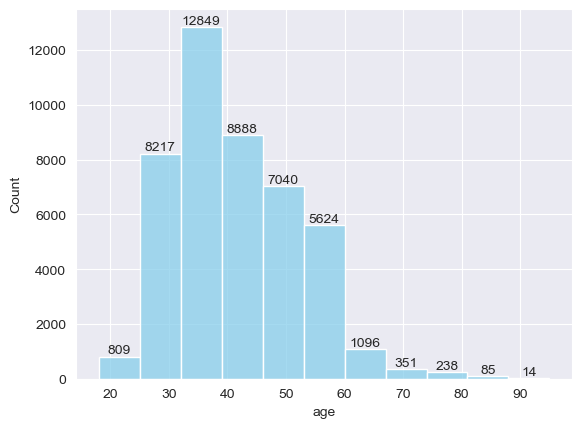

In [15]:
# Age distribution plot
sns.set_palette("Pastel1")
sns.set_style("darkgrid")

ax = sns.histplot(data=data, x='age', color='skyblue', bins = 70, binwidth = 7)
# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container)
plt.show()

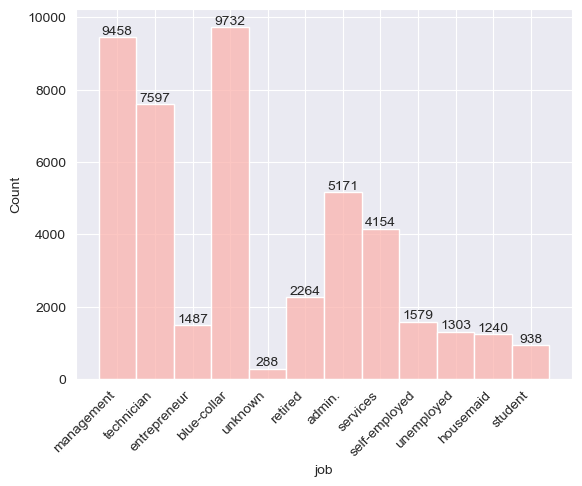

In [17]:
jx = sns.histplot(x = 'job', data=data, binwidth = 50)
plt.xticks(rotation=45,horizontalalignment='right');
for container in jx.containers:
    jx.bar_label(container)
plt.show()

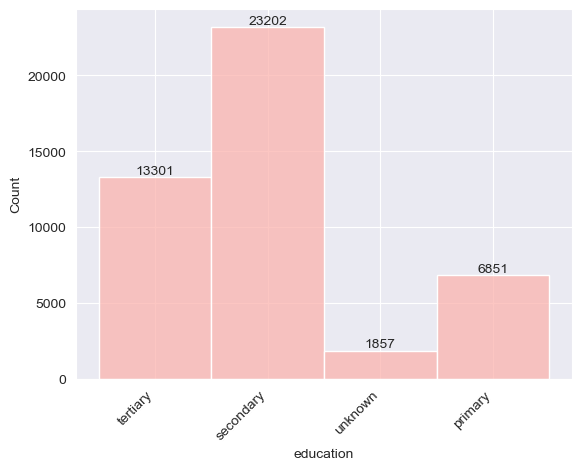

In [19]:
ex = sns.histplot(x = 'education', data=data, binwidth = 50)
plt.xticks(rotation=45,horizontalalignment='right');

for container in ex.containers:
    ex.bar_label(container)
plt.show()

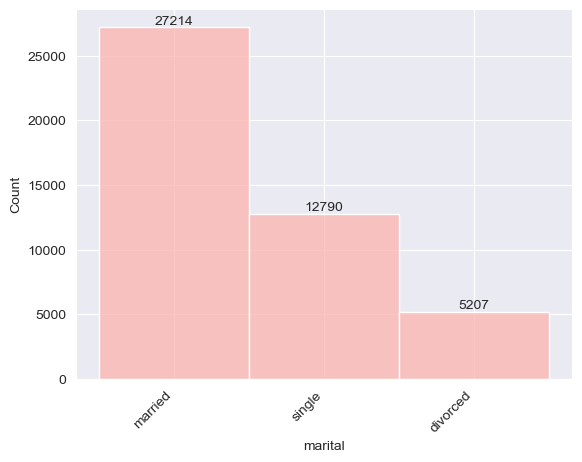

In [21]:
mx = sns.histplot(x = 'marital', data=data, binwidth = 50)
plt.xticks(rotation=45,horizontalalignment='right');
for container in mx.containers:
    mx.bar_label(container)
plt.show()

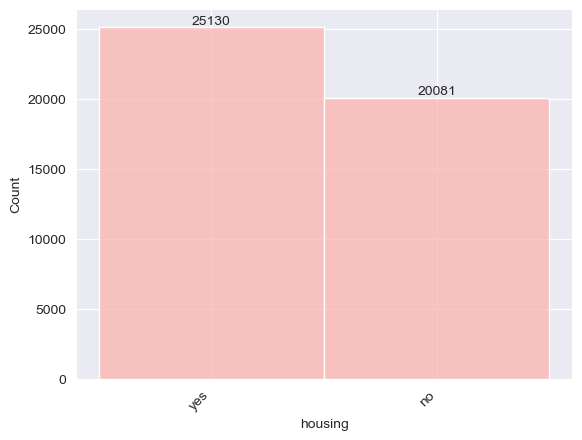

In [23]:
hx = sns.histplot(x = 'housing', data=data, binwidth = 50)
plt.xticks(rotation=45,horizontalalignment='right');

for container in hx.containers:
    hx.bar_label(container)
plt.show()

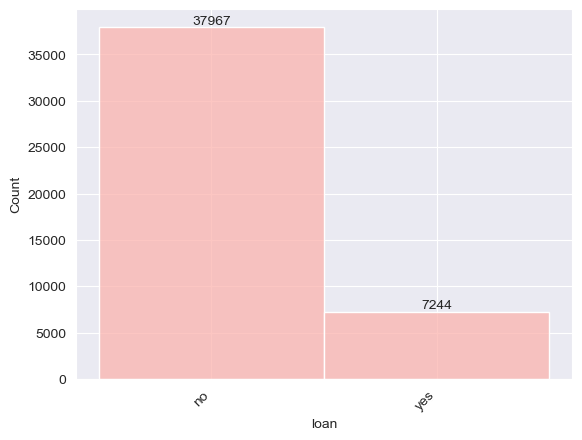

In [25]:
lx = sns.histplot(x = 'loan', data=data, binwidth = 50)
plt.xticks(rotation=45,horizontalalignment='right');

for container in lx.containers:
    lx.bar_label(container)
plt.show()

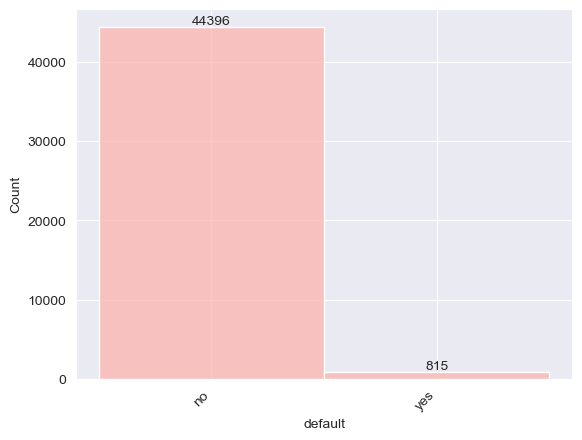

In [27]:
dx = sns.histplot(x = 'default', data=data, binwidth = 50)
plt.xticks(rotation=45,horizontalalignment='right');

for container in dx.containers:
    dx.bar_label(container)
plt.show()

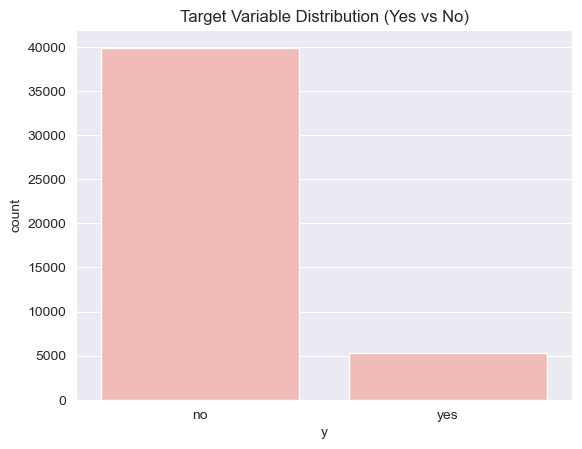

In [29]:
sns.countplot(x='y', data=data)
plt.title('Target Variable Distribution (Yes vs No)')
plt.show()

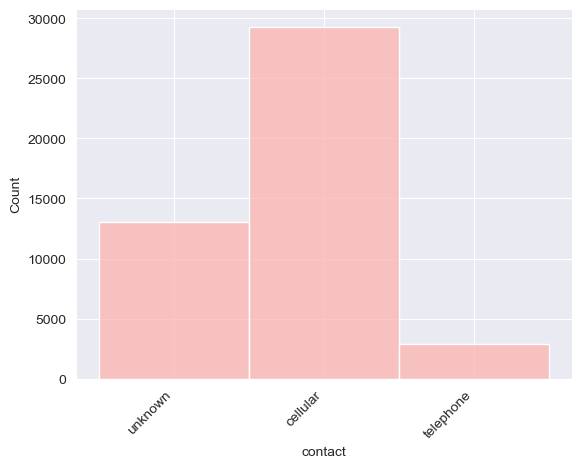

In [70]:
ux = sns.histplot(x = 'contact', data=data, binwidth = 50)
plt.xticks(rotation=45,horizontalalignment='right');

for container in ux.containers:
    lx.bar_label(container)
plt.show()

Kernel density plots help visualize the distribution of data and identify patterns such as skewness and density.

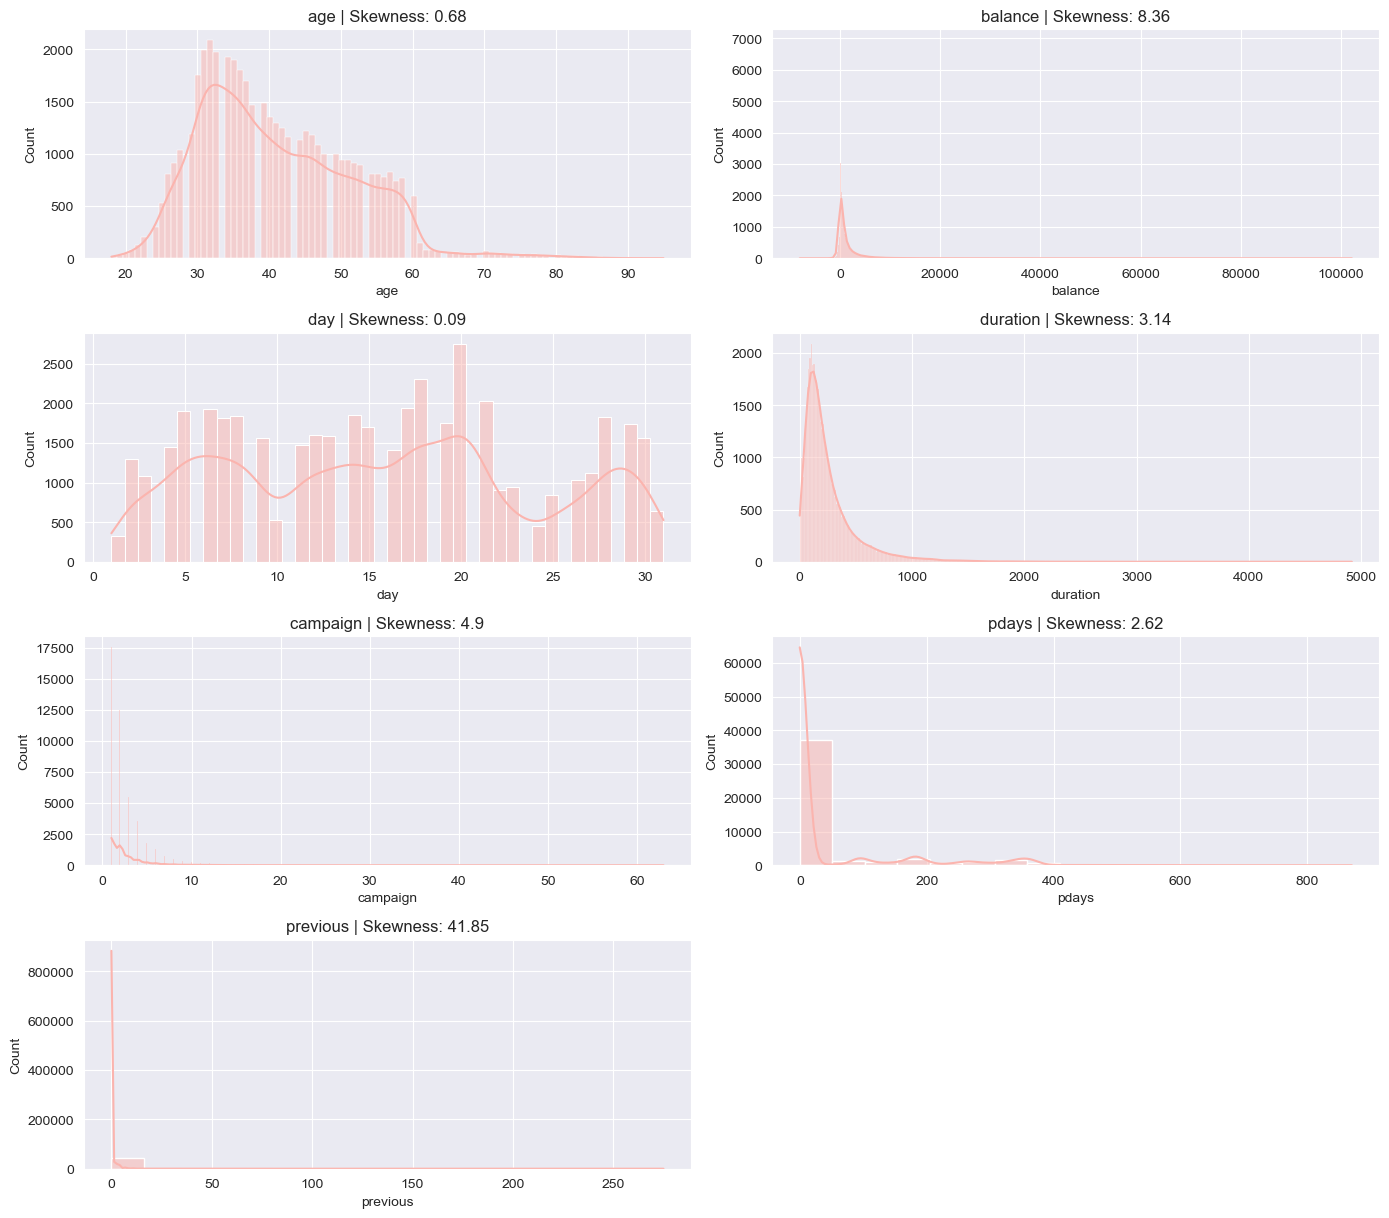

In [32]:
sns.set_style("darkgrid")

numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(data[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(data[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

1. The vast majority of bank clients are young people between 31-35 as can be seen on the first right-skewed distribution.
2. The balance distribution is also right-skewed, approximately 2000 clients have a balance account with little bit over that 10K.
3. Days distribution - 20th day of the month was the last contact day for more that 2500 users, whereas on the first day minimum amount of bank managers contacted clients(≈200)
4. Duration distribution displays that vast majority of clients used the bank account after the last contact in less that 500 seconds(≈8,5 minutes). Leaks target informations, useless for A/B testing.
5. Campaign distribution shows how many contact were made with clients: ≈17500 clients had 1 contact, ≈12500 clients had 2 contacts, ≈500 clients had 3 contacts, rarely there were more than 10 contacts.
6. This distribution shows that bank did not contact the vast majority of clients after the prior campaign. 
7. A small group was contacted 1–10 times previously, and there are extreme outliers reaching up to 275 prior contacts which are almost certainly data errors — no real campaign contacts a single person 275 times.

#### Bivariate Analysis

<Figure size 1000x600 with 0 Axes>

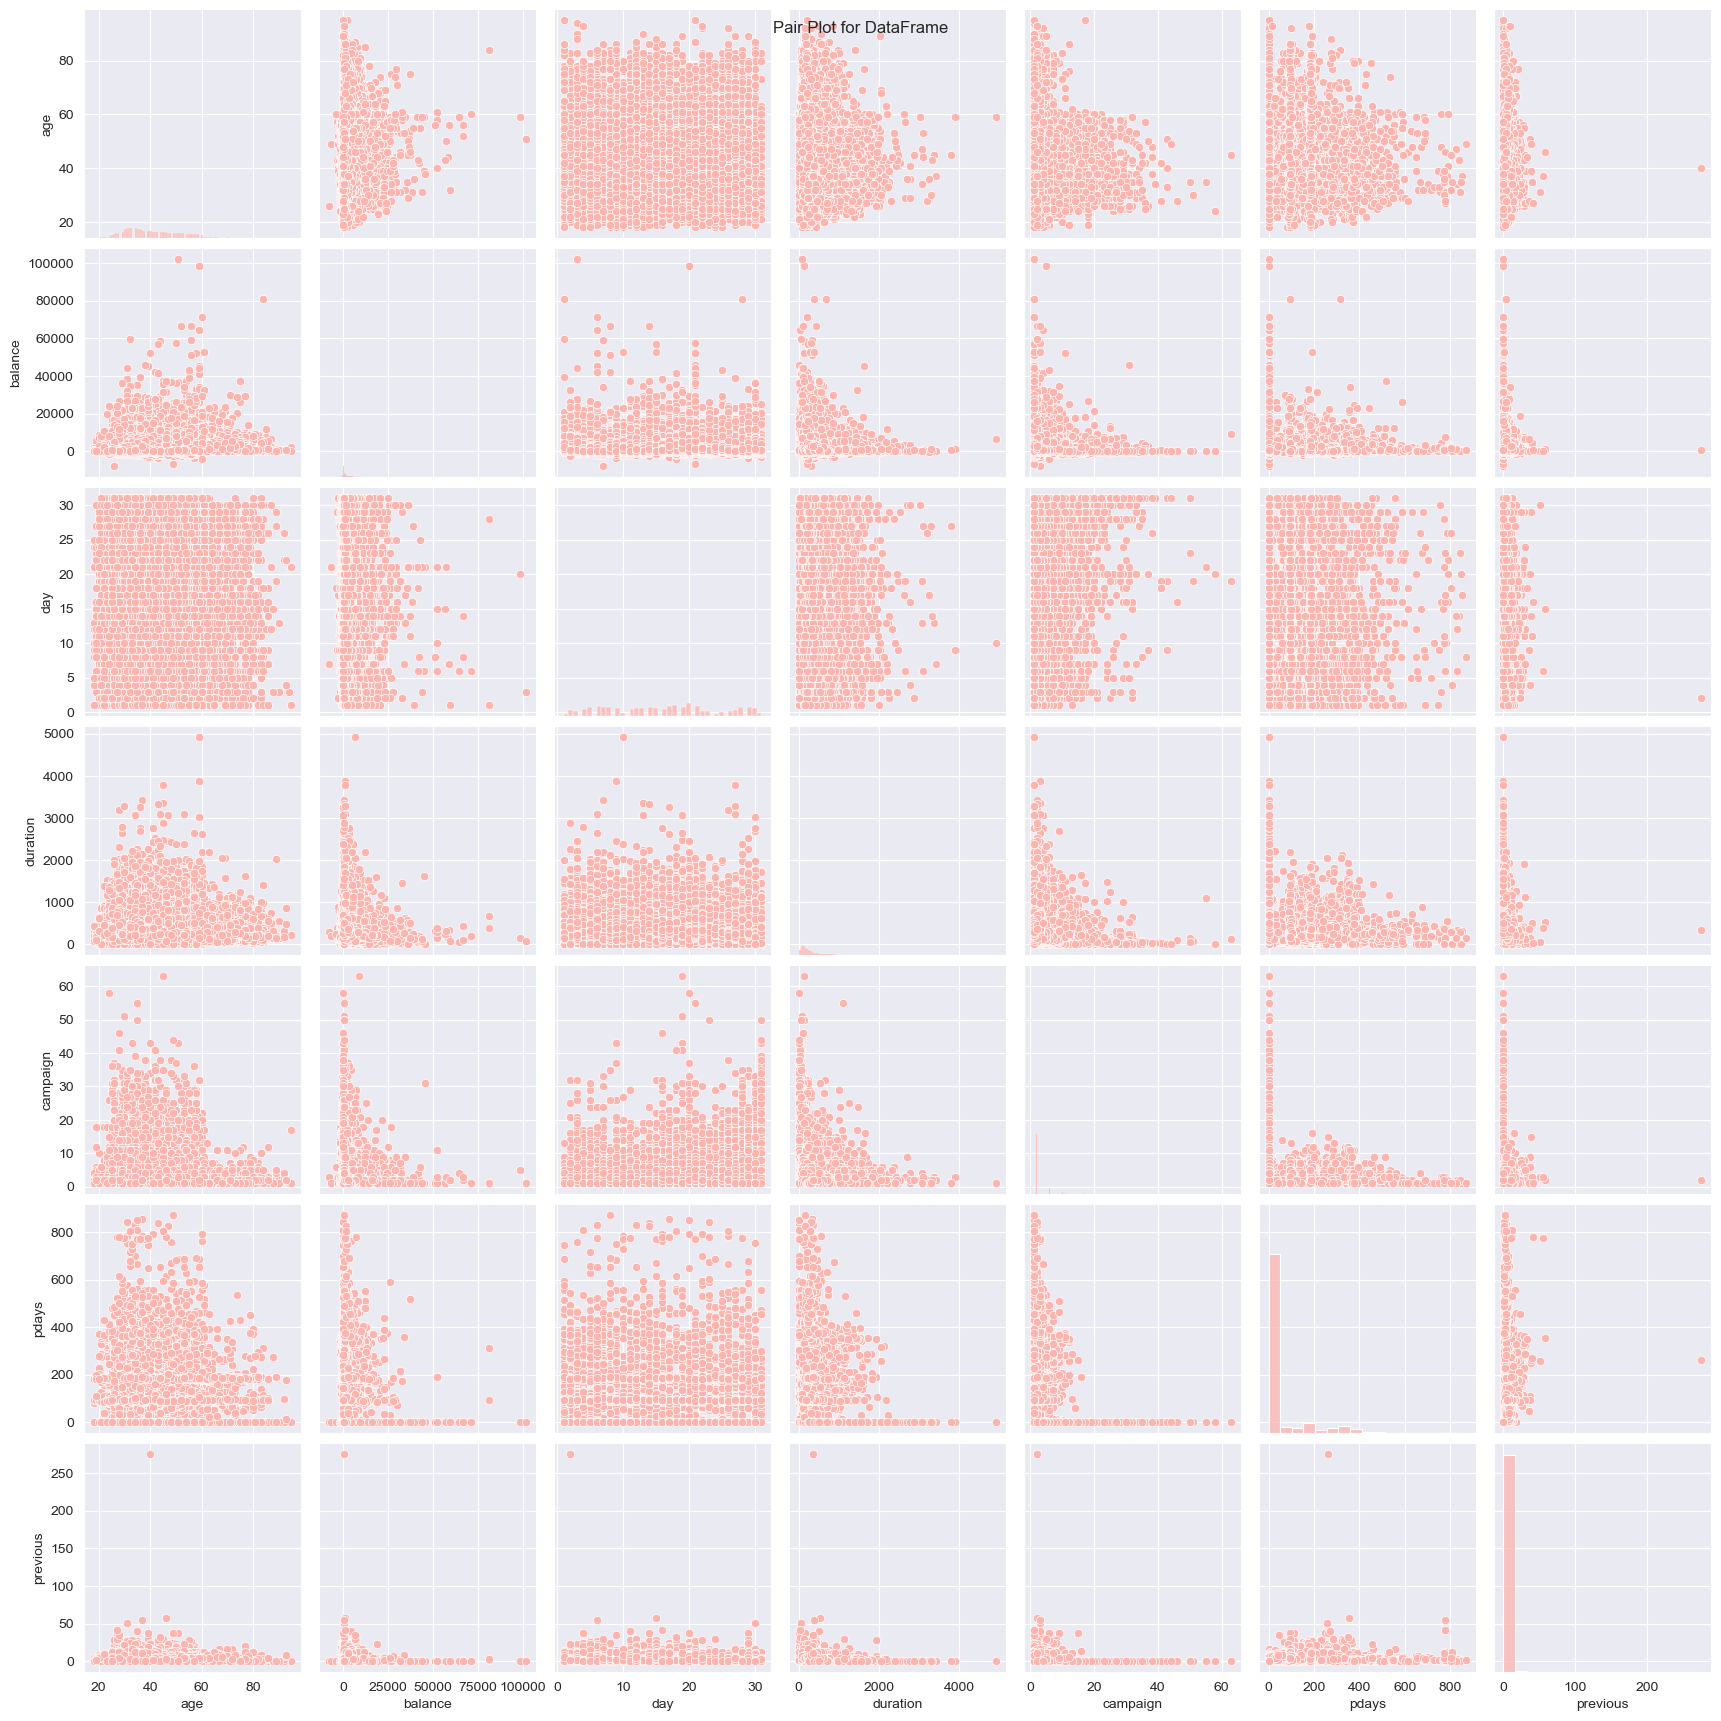

In [35]:
plt.figure(figsize=(10, 6))

sns.pairplot(data)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

<Axes: xlabel='y', ylabel='age'>

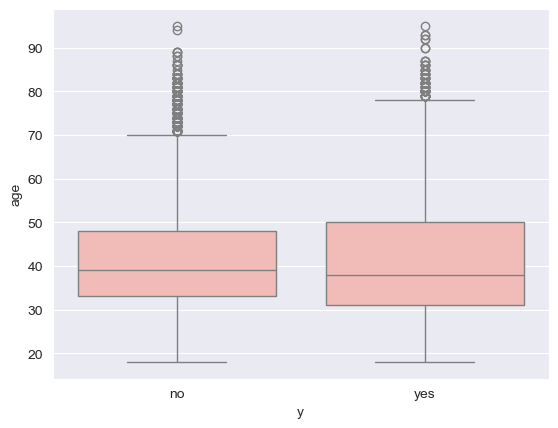

In [36]:
sns.boxplot(x='y', y='age', data=data)

#### Multivariate Analysis

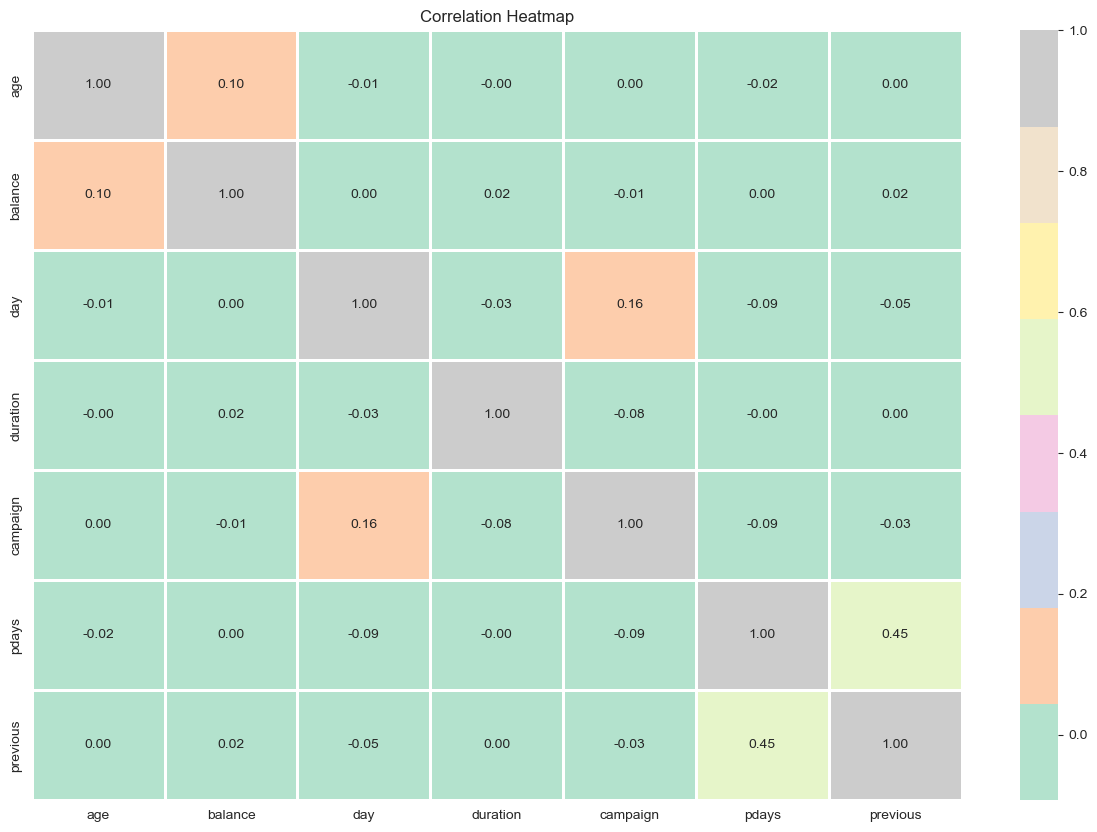

In [38]:
plt.figure(figsize=(15, 10))

sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

#### Main questions that are helpful to build A/B test:

What's the overall conversion rate?
Which contact month had the highest conversion?
Does call duration correlate with conversion?
Which job types convert best?
Does previous campaign contact affect current outcome?

#### Visualizations to build:

Conversion rate by job type (bar chart)
Conversion rate by month (bar chart)
Call duration distribution: converted vs not (overlapping histogram)
Age distribution by outcome (boxplot) give me hints how to answer these questions

In [41]:
# Overall conversion rate

data['y'] = data['y'].replace({'no': 0, 'yes': 1})
conversion_rate = data['y'].sum() / data['y'].count()
print(f"Conversion rate: {conversion_rate:.2%}")


Conversion rate: 11.70%


/var/folders/qd/c6k1xjg13198z19m9c7gx9280000gn/T/ipykernel_29742/204226039.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['y'] = data['y'].replace({'no': 0, 'yes': 1})


In [46]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

month_conv = data.groupby('month')['y'].mean().reindex(month_order)

print(f'Conversion rate by month:\n{month_conv.round(3)}')
print(f'\nHighest converting month: {month_conv.idxmax()} ({month_conv.max():.1%})')

Conversion rate by month:
month
jan    0.101
feb    0.166
mar    0.520
apr    0.197
may    0.067
jun    0.102
jul    0.091
aug    0.110
sep    0.465
oct    0.438
nov    0.102
dec    0.467
Name: y, dtype: float64

Highest converting month: mar (52.0%)


/var/folders/qd/c6k1xjg13198z19m9c7gx9280000gn/T/ipykernel_29742/3739030279.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_conv.index, y=month_conv.values, palette='Pastel2')


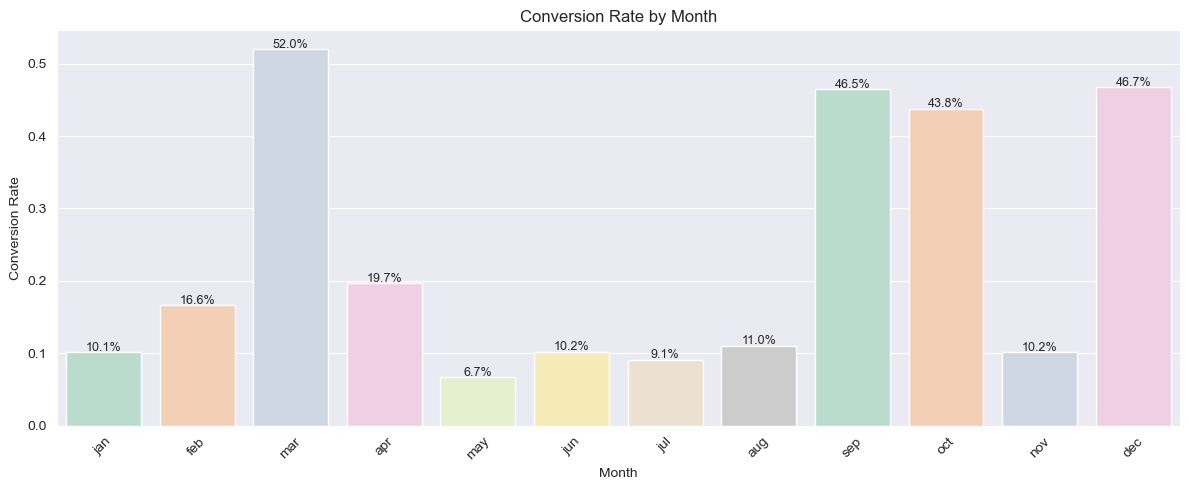

In [48]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

month_conv = (data.groupby('month')['y']
              .mean()
              .reindex(month_order))

plt.figure(figsize=(12, 5))
sns.barplot(x=month_conv.index, y=month_conv.values, palette='Pastel2')
plt.title('Conversion Rate by Month')
plt.xlabel('Month')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)

# add value labels on top of each bar
for i, v in enumerate(month_conv.values):
    plt.text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [58]:
# Call duration correlation with target

# Numeric correlation
data['y_binary'] = (data['y'] == 1).astype(int)
data[['duration', 'y_binary']].corr()

,duration,y_binary
duration,1.000000,0.394521
y_binary,0.394521,1.000000


(0.0, 3000.0)

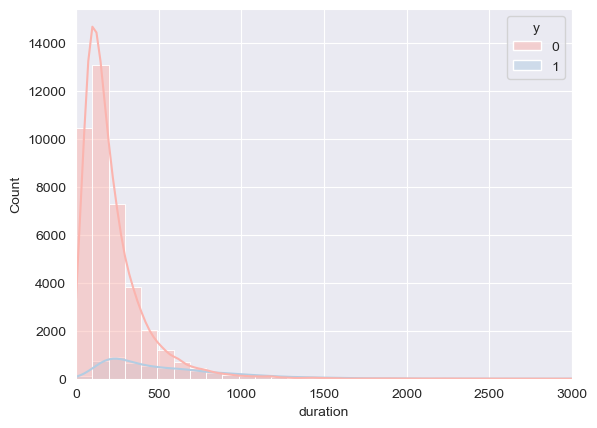

In [60]:
sns.histplot(data=data, x='duration', hue='y', 
             bins=50, alpha=0.5, kde=True)
plt.xlim(0, 3000)  # cut extreme outliers for readability

In [54]:
# Job types that awere converted best
job_conv = data.groupby('job')['y'].mean().sort_values(ascending=False)

print(f'Conversion rate by job type:\n{job_conv.round(3)}')
print(f'\nBest converting job: {job_conv.idxmax()} ({job_conv.max():.1%})')

Conversion rate by job type:
job
student          0.287
retired          0.228
unemployed       0.155
management       0.138
admin.           0.122
self-employed    0.118
unknown          0.118
technician       0.111
services         0.089
housemaid        0.088
entrepreneur     0.083
blue-collar      0.073
Name: y, dtype: float64

Best converting job: student (28.7%)


/var/folders/qd/c6k1xjg13198z19m9c7gx9280000gn/T/ipykernel_29742/1381764873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_conv.values, y=job_conv.index, palette='Pastel2')


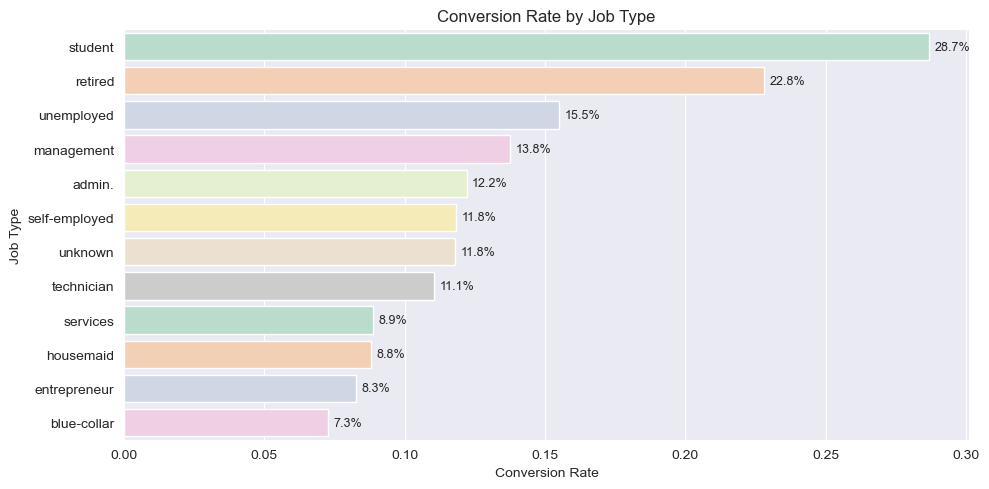

In [56]:
# Bar plot to visualise job types convertion
plt.figure(figsize=(10, 5))
sns.barplot(x=job_conv.values, y=job_conv.index, palette='Pastel2')
plt.title('Conversion Rate by Job Type')
plt.xlabel('Conversion Rate')
plt.ylabel('Job Type')

for i, v in enumerate(job_conv.values):
    plt.text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [62]:
#Does previous contact affect outcome?

data['is_returning'] = (data['previous'] > 0).astype(int)
data.groupby('is_returning')['y_binary'].mean()

is_returning
0    0.091573
1    0.230713
Name: y_binary, dtype: float64

#### Finding: 

1. Students and retired people are the groups of peopple who converted most with 28.7% and 22% respectively.
- It is interesting to find out that 15%  ofunemployed people are converted to open deposit in a bank, whereas entrepreneurs converted with 8,3%. Blue-collar jobs are the least converted.
  
2. Clients with at least one prior campaign contact convert at 23.1% vs 9.2% 
for first-time contacts — a 2.5x difference.
- This suggests that familiarity with the bank's offerings significantly  increases willingness to subscribe. In a real campaign setting, this would  justify prioritizing re-engagement of previously contacted clients before acquiring new ones, as CAC (cost of acquisition) would be substantially lower.

3. Converted clients had significantly longer call durations (median ~500s) vs non-converted clients (median ~150s).
- Longer engagement on the call strongly signals purchase intent.

4. March is the month of highest conversion-52%, September and December approx. 46%, and October has 43.8% of conversion.
but significantly fewer total contacts than May.
- May's low conversion rate (~6%) is partly explained by it being the highest volume month — 
mass outreach campaigns typically yield lower conversion than targeted ones.

5. Prior Contact History Strongly Predicts Conversion

In [74]:
data_clean = data.copy()
data_clean.to_csv('cleaned_data.csv', index=False)